# Cross-Dataset QC Metrics Comparison

Compare gene and guide mapping metrics across the TFP3 production datasets.

**Input:** `manifests/manifest.tsv`
**Output:** Combined metrics TSVs and comparison barplots under `results/cross_dataset_metrics/`

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
# Project root and color loader
PROJECT_ROOT = Path("/cellar/users/aklie/projects/tf_perturb_seq")
sys.path.append(str(PROJECT_ROOT / "config"))
from loader import load_colors

PALETTE = "production_TF-Perturb-seq"
dataset_colors = load_colors(PALETTE, "dataset_colors")
dataset_order = load_colors(PALETTE, "dataset_order")

In [5]:
# Paths
BASE_DIR = PROJECT_ROOT / "docs" / "jamborees" / "2026_UTSW" / "working_groups" / "wg1_data_qc" / "pipeline_qc"
QC_PATHS_FILE = BASE_DIR / "manifest.tsv"
OUTPUT_DIR = BASE_DIR / "results" / "cross_dataset_metrics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Manifest:     {QC_PATHS_FILE}")
print(f"Output dir:   {OUTPUT_DIR}")

Manifest:     /cellar/users/aklie/projects/tf_perturb_seq/docs/jamborees/2026_UTSW/working_groups/wg1_data_qc/pipeline_qc/manifest.tsv
Output dir:   /cellar/users/aklie/projects/tf_perturb_seq/docs/jamborees/2026_UTSW/working_groups/wg1_data_qc/pipeline_qc/results/cross_dataset_metrics


In [6]:
# Load manifest. Only keep rows whose dataset is in the palette dataset_order
# so dropdown order / colors stay aligned. Datasets not yet onboarded are skipped.
paths_df = pd.read_csv(QC_PATHS_FILE, sep="\t")
paths_df = paths_df[paths_df['dataset'].isin(dataset_order)].copy()
paths_df['dataset'] = pd.Categorical(paths_df['dataset'], categories=dataset_order, ordered=True)
paths_df = paths_df.sort_values('dataset').reset_index(drop=True)

# Short-name lookup: prefer the manifest's column, but build a fallback in case
# a future row leaves it blank.
short_by_dataset = dict(zip(paths_df['dataset'], paths_df['short_name']))
present_datasets = list(paths_df['dataset'])
present_short_names = [short_by_dataset[ds] for ds in present_datasets]
color_by_short = {short_by_dataset[ds]: dataset_colors[ds] for ds in present_datasets}

paths_df

,dataset,short_name,run,params_source,params_json,dashboard_source_type,dashboard_source_uri,dashboard_local,ENABLE_DATA_HASHING,use_igvf_reference,...,base_container,max_cpus,max_memory_GB,qc_dir,gene_metrics,guide_metrics,per_guide_capture,intended_target_results,intended_target_metrics,mudata
0,Hon_WTC11-cardiomyocyte-differentiation_TF-Per...,Hon CM,2026_04_19_no_spacer,"Synapse syn74918982 (Weizhou Qian, UMich)",/cellar/users/aklie/projects/tf_perturb_seq/da...,synapse,syn74526326,/cellar/users/aklie/projects/tf_perturb_seq/sc...,True,False,...,ghcr.io/pinellolab/crispr_pipeline/conda-docke...,16,1500,/cellar/users/aklie/projects/tf_perturb_seq/da...,mapping_gene/HonCM_weizhou_gene_metrics.tsv,mapping_guide/HonCM_weizhou_guide_metrics.tsv,mapping_guide/HonCM_weizhou_guide_per_guide_ca...,intended_target/HonCM_weizhou_intended_target_...,intended_target/HonCM_weizhou_intended_target_...,/cellar/users/aklie/projects/tf_perturb_seq/da...
1,Huangfu_HUES8-definitive-endoderm-differentiat...,Huangfu DE,muddy_penguin,GCS gs://igvf-pertub-seq-pipeline-data/.../mud...,/cellar/users/aklie/projects/tf_perturb_seq/da...,gcs,gs://igvf-pertub-seq-pipeline-data/Huangfu_HUE...,/cellar/users/aklie/projects/tf_perturb_seq/sc...,False,True,...,sjiang9/conda-docker:0.3,128,256,/cellar/users/aklie/projects/tf_perturb_seq/da...,mapping_gene/HuangfuDE_muddy_penguin_gene_metr...,mapping_guide/HuangfuDE_muddy_penguin_guide_me...,mapping_guide/HuangfuDE_muddy_penguin_guide_pe...,intended_target/HuangfuDE_muddy_penguin_intend...,intended_target/HuangfuDE_muddy_penguin_intend...,/cellar/users/aklie/projects/tf_perturb_seq/da...
2,Huangfu_HUES8-embryonic-stemcell-differentiati...,Huangfu ESC,qc_barcode_filter_none,GCS gs://igvf-pertub-seq-pipeline-data/.../qc_...,/cellar/users/aklie/projects/tf_perturb_seq/da...,gcs,gs://igvf-pertub-seq-pipeline-data/Huangfu_HUE...,/cellar/users/aklie/projects/tf_perturb_seq/da...,False,True,...,sjiang9/conda-docker:0.3,128,256,/cellar/users/aklie/projects/tf_perturb_seq/da...,mapping_gene/HuangfuESC_qc_barcode_filter_none...,mapping_guide/HuangfuESC_qc_barcode_filter_non...,mapping_guide/HuangfuESC_qc_barcode_filter_non...,intended_target/HuangfuESC_qc_barcode_filter_n...,intended_target/HuangfuESC_qc_barcode_filter_n...,/cellar/users/aklie/projects/tf_perturb_seq/da...
3,Gersbach_WTC11-hepatocyte-differentiation_TF-P...,Gersbach Hep,sara_synapse_syn74842722,"Synapse syn74902800 (Sara Geraghty, Duke HPC)",/cellar/users/aklie/projects/tf_perturb_seq/da...,synapse,syn74843827,/cellar/users/aklie/projects/tf_perturb_seq/sc...,False,True,...,ghcr.io/pinellolab/crispr_pipeline/conda-docke...,12,600,/cellar/users/aklie/projects/tf_perturb_seq/da...,mapping_gene/GersbachHep_sara_synapse_gene_met...,mapping_guide/GersbachHep_sara_synapse_guide_m...,mapping_guide/GersbachHep_sara_synapse_guide_p...,intended_target/GersbachHep_sara_synapse_inten...,intended_target/GersbachHep_sara_synapse_inten...,/cellar/users/aklie/projects/tf_perturb_seq/da...


## Gene Metrics

In [7]:
# Load and combine gene metrics
gene_metrics_list = []
for _, row in paths_df.iterrows():
    gene_path = Path(row['qc_dir']) / row['gene_metrics']
    if gene_path.exists():
        df = pd.read_csv(gene_path, sep="\t")
        df['dataset'] = row['dataset']
        df['short_name'] = row['short_name']
        gene_metrics_list.append(df)
    else:
        print(f"Warning: {gene_path} not found")

gene_metrics_df = pd.concat(gene_metrics_list, ignore_index=True)
gene_metrics_df.head()

,batch,n_cells,umi_median,umi_mean,umi_std,umi_min,umi_max,umi_q25,umi_q75,genes_median,...,genes_q75,mito_median,mito_mean,mito_std,mito_min,mito_max,mito_q25,mito_q75,dataset,short_name
0,all,1004091,2398.0,2502.3410,1638.8444,75.0,58346.0,1441.00,3383.0,1426.0,...,1855.0,3.592814,4.139559,2.869516,0.0,14.998764,2.081201,5.565142,Hon_WTC11-cardiomyocyte-differentiation_TF-Per...,Hon CM
1,IGVFDS0119GHBM,35038,2508.0,2544.3716,1762.4977,75.0,20965.0,1241.25,3534.0,1470.0,...,1902.0,4.269479,4.730840,3.092248,0.0,14.997956,2.439024,6.492919,Hon_WTC11-cardiomyocyte-differentiation_TF-Per...,Hon CM
2,IGVFDS0814DYDR,38859,3031.0,2995.2854,1816.6370,75.0,29433.0,1923.00,3997.0,1705.0,...,2096.0,3.063291,3.535156,2.478698,0.0,14.987440,1.890100,4.594594,Hon_WTC11-cardiomyocyte-differentiation_TF-Per...,Hon CM
3,IGVFDS0860HOHE,41117,2591.0,2660.0208,1631.3800,75.0,20463.0,1678.00,3540.0,1543.0,...,1941.0,3.139357,3.595859,2.484879,0.0,14.993700,1.928873,4.684685,Hon_WTC11-cardiomyocyte-differentiation_TF-Per...,Hon CM
4,IGVFDS1042ITOF,39931,2349.0,2326.9805,1354.1162,75.0,17045.0,1531.00,3073.0,1396.0,...,1728.0,3.031437,3.490807,2.446731,0.0,14.982578,1.828468,4.562184,Hon_WTC11-cardiomyocyte-differentiation_TF-Per...,Hon CM


In [8]:
gene_metrics_df.to_csv(OUTPUT_DIR / "combined_gene_metrics.tsv", sep="\t", index=False)
print(f"Saved to {OUTPUT_DIR / 'combined_gene_metrics.tsv'}")

Saved to /cellar/users/aklie/projects/tf_perturb_seq/docs/jamborees/2026_UTSW/working_groups/wg1_data_qc/pipeline_qc/results/cross_dataset_metrics/combined_gene_metrics.tsv


In [9]:
# Aggregate row ('all') per dataset
gene_all = gene_metrics_df[gene_metrics_df['batch'] == 'all'].copy()
gene_all['dataset'] = pd.Categorical(gene_all['dataset'], categories=present_datasets, ordered=True)
gene_all = gene_all.sort_values('dataset').reset_index(drop=True)
gene_all

,batch,n_cells,umi_median,umi_mean,umi_std,umi_min,umi_max,umi_q25,umi_q75,genes_median,...,genes_q75,mito_median,mito_mean,mito_std,mito_min,mito_max,mito_q25,mito_q75,dataset,short_name
0,all,1004091,2398.0,2502.341,1638.8444,75.0,58346.0,1441.0,3383.0,1426.0,...,1855.0,3.592814,4.139559,2.869516,0.0,14.998764,2.081201,5.565142,Hon_WTC11-cardiomyocyte-differentiation_TF-Per...,Hon CM
1,all,269491,5818.0,5306.607,4225.0913,36.0,54219.0,81.0,7882.0,3018.0,...,3688.0,3.979025,3.941471,2.025995,0.0,19.985250,3.068401,4.730229,Huangfu_HUES8-definitive-endoderm-differentiat...,Huangfu DE
2,all,130789,7246.0,7714.890,2999.7988,557.0,45347.0,5809.0,9087.0,3360.0,...,3899.0,7.597015,7.637666,1.835248,0.0,19.994180,6.710688,8.488794,Huangfu_HUES8-embryonic-stemcell-differentiati...,Huangfu ESC
3,all,1053820,10504.0,11106.376,4066.6572,4022.0,193069.0,8101.0,13359.0,3623.0,...,4197.0,2.646836,3.370593,2.421813,0.0,14.999744,1.797803,4.120575,Gersbach_WTC11-hepatocyte-differentiation_TF-P...,Gersbach Hep


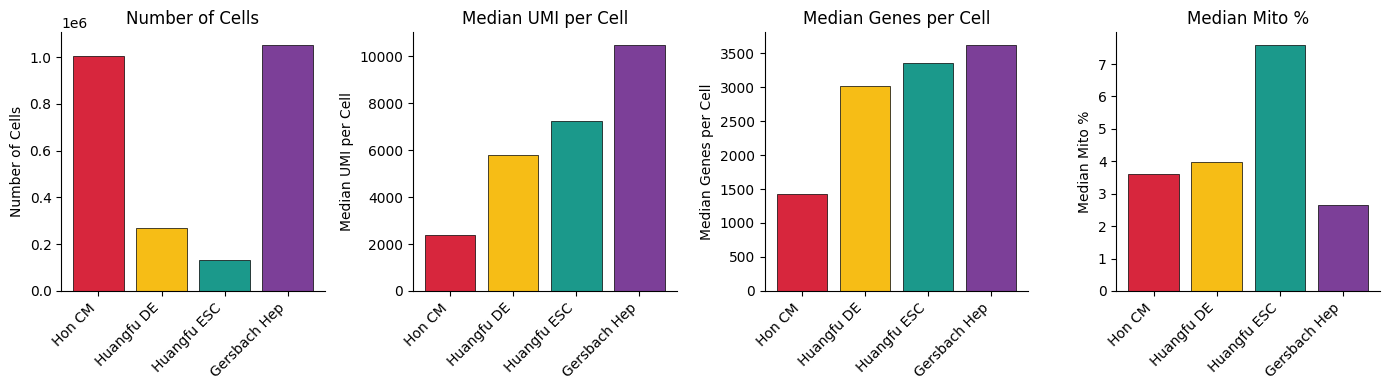

In [10]:
# Aggregate gene-metric barplots
gene_metrics_to_plot = [
    ('n_cells', 'Number of Cells'),
    ('umi_median', 'Median UMI per Cell'),
    ('genes_median', 'Median Genes per Cell'),
    ('mito_median', 'Median Mito %'),
]
gene_metrics_to_plot = [(c, t) for c, t in gene_metrics_to_plot if c in gene_all.columns]

fig, axes = plt.subplots(1, len(gene_metrics_to_plot), figsize=(3.5 * len(gene_metrics_to_plot), 4))
if len(gene_metrics_to_plot) == 1:
    axes = [axes]

for ax, (col, title) in zip(axes, gene_metrics_to_plot):
    colors = [dataset_colors[ds] for ds in gene_all['dataset']]
    ax.bar(range(len(gene_all)), gene_all[col], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(gene_all)))
    ax.set_xticklabels(gene_all['short_name'], rotation=45, ha='right')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
for ext in ("pdf", "png"):
    plt.savefig(OUTPUT_DIR / f"gene_metrics_comparison.{ext}", dpi=300, bbox_inches='tight')
plt.show()

## Guide Metrics

In [11]:
# Load and combine guide metrics
guide_metrics_list = []
for _, row in paths_df.iterrows():
    guide_path = Path(row['qc_dir']) / row['guide_metrics']
    if guide_path.exists():
        df = pd.read_csv(guide_path, sep="\t")
        df['dataset'] = row['dataset']
        df['short_name'] = row['short_name']
        guide_metrics_list.append(df)
    else:
        print(f"Warning: {guide_path} not found")

guide_metrics_df = pd.concat(guide_metrics_list, ignore_index=True)
guide_metrics_df.head()

,batch,n_cells,guide_umi_median,guide_umi_mean,guide_umi_std,guide_umi_min,guide_umi_max,guide_umi_q25,guide_umi_q75,guides_per_cell_mean,...,n_cells_exactly_1_guide,frac_cells_with_guide,n_guides_total,cells_per_guide_median,cells_per_guide_mean,cells_per_guide_std,cells_per_guide_min,cells_per_guide_max,dataset,short_name
0,all,1004091,303.0,528.382099,646.491679,1.0,12863.0,65.0,739.0,2.691406,...,212264,0.971140,14151.0,147.0,190.970037,228.644492,0.0,9532.0,Hon_WTC11-cardiomyocyte-differentiation_TF-Per...,Hon CM
1,IGVFDS0119GHBM,35038,197.0,453.933044,690.284263,1.0,12486.0,43.0,547.0,2.638906,...,7606,0.956048,NaN,NaN,NaN,NaN,NaN,NaN,Hon_WTC11-cardiomyocyte-differentiation_TF-Per...,Hon CM
2,IGVFDS0814DYDR,38859,341.0,544.447412,626.573805,1.0,6138.0,70.0,780.0,2.711135,...,7903,0.977869,NaN,NaN,NaN,NaN,NaN,NaN,Hon_WTC11-cardiomyocyte-differentiation_TF-Per...,Hon CM
3,IGVFDS0860HOHE,41117,346.0,548.743099,627.754842,1.0,7851.0,83.0,780.0,2.693606,...,8634,0.976093,NaN,NaN,NaN,NaN,NaN,NaN,Hon_WTC11-cardiomyocyte-differentiation_TF-Per...,Hon CM
4,IGVFDS1042ITOF,39931,322.0,509.588390,574.089464,1.0,5852.0,73.0,729.0,2.615061,...,8777,0.972102,NaN,NaN,NaN,NaN,NaN,NaN,Hon_WTC11-cardiomyocyte-differentiation_TF-Per...,Hon CM


In [12]:
guide_metrics_df.to_csv(OUTPUT_DIR / "combined_guide_metrics.tsv", sep="\t", index=False)
print(f"Saved to {OUTPUT_DIR / 'combined_guide_metrics.tsv'}")

Saved to /cellar/users/aklie/projects/tf_perturb_seq/docs/jamborees/2026_UTSW/working_groups/wg1_data_qc/pipeline_qc/results/cross_dataset_metrics/combined_guide_metrics.tsv


In [13]:
guide_all = guide_metrics_df[guide_metrics_df['batch'] == 'all'].copy()
guide_all['dataset'] = pd.Categorical(guide_all['dataset'], categories=present_datasets, ordered=True)
guide_all = guide_all.sort_values('dataset').reset_index(drop=True)
guide_all

,batch,n_cells,guide_umi_median,guide_umi_mean,guide_umi_std,guide_umi_min,guide_umi_max,guide_umi_q25,guide_umi_q75,guides_per_cell_mean,...,n_cells_exactly_1_guide,frac_cells_with_guide,n_guides_total,cells_per_guide_median,cells_per_guide_mean,cells_per_guide_std,cells_per_guide_min,cells_per_guide_max,dataset,short_name
0,all,1004091,303.0,528.382099,646.491679,1.0,12863.0,65.0,739.0,2.691406,...,212264,0.971140,14151.0,147.0,190.970037,228.644492,0.0,9532.0,Hon_WTC11-cardiomyocyte-differentiation_TF-Per...,Hon CM
1,all,269491,372.0,634.784564,833.488000,1.0,13635.0,11.0,906.0,6.972307,...,29153,0.905307,14151.0,94.0,132.780298,166.385163,0.0,6134.0,Huangfu_HUES8-definitive-endoderm-differentiat...,Huangfu DE
2,all,130789,2449.0,2981.012532,2279.238645,1.0,25745.0,1369.0,4002.0,10.899326,...,1326,0.998838,14151.0,71.0,100.735778,129.584000,0.0,5289.0,Huangfu_HUES8-embryonic-stemcell-differentiati...,Huangfu ESC
3,all,1053820,527.0,943.908819,1150.448570,1.0,35082.0,149.0,1333.0,2.047702,...,258968,0.797898,14151.0,103.0,152.491626,258.404366,0.0,14278.0,Gersbach_WTC11-hepatocyte-differentiation_TF-P...,Gersbach Hep


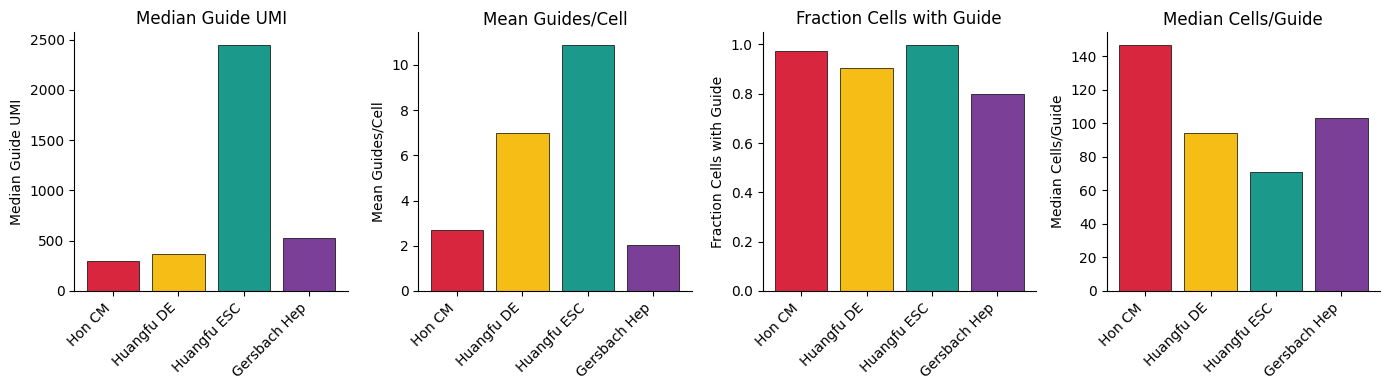

In [14]:
# Aggregate guide-metric barplots
guide_metrics_to_plot = [
    ('guide_umi_median', 'Median Guide UMI'),
    ('guides_per_cell_mean', 'Mean Guides/Cell'),
    ('frac_cells_with_guide', 'Fraction Cells with Guide'),
    ('cells_per_guide_median', 'Median Cells/Guide'),
]
guide_metrics_to_plot = [(c, t) for c, t in guide_metrics_to_plot if c in guide_all.columns]

fig, axes = plt.subplots(1, len(guide_metrics_to_plot), figsize=(3.5 * len(guide_metrics_to_plot), 4))
if len(guide_metrics_to_plot) == 1:
    axes = [axes]

for ax, (col, title) in zip(axes, guide_metrics_to_plot):
    colors = [dataset_colors[ds] for ds in guide_all['dataset']]
    ax.bar(range(len(guide_all)), guide_all[col], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(guide_all)))
    ax.set_xticklabels(guide_all['short_name'], rotation=45, ha='right')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
for ext in ("pdf", "png"):
    plt.savefig(OUTPUT_DIR / f"guide_metrics_comparison.{ext}", dpi=300, bbox_inches='tight')
plt.show()

## Combined Summary Table

In [15]:
gene_summary_cols = ['dataset', 'short_name', 'n_cells', 'umi_median', 'mito_median']
if 'genes_median' in gene_all.columns:
    gene_summary_cols.insert(-1, 'genes_median')

summary = gene_all[gene_summary_cols].merge(
    guide_all[['dataset', 'guide_umi_median', 'guides_per_cell_median',
               'frac_cells_with_guide', 'cells_per_guide_median']],
    on='dataset'
)
summary.to_csv(OUTPUT_DIR / "metrics_summary.tsv", sep="\t", index=False)
print(f"Saved to {OUTPUT_DIR / 'metrics_summary.tsv'}")
summary

Saved to /cellar/users/aklie/projects/tf_perturb_seq/docs/jamborees/2026_UTSW/working_groups/wg1_data_qc/pipeline_qc/results/cross_dataset_metrics/metrics_summary.tsv


,dataset,short_name,n_cells,umi_median,genes_median,mito_median,guide_umi_median,guides_per_cell_median,frac_cells_with_guide,cells_per_guide_median
0,Hon_WTC11-cardiomyocyte-differentiation_TF-Per...,Hon CM,1004091,2398.0,1426.0,3.592814,303.0,2.0,0.971140,147.0
1,Huangfu_HUES8-definitive-endoderm-differentiat...,Huangfu DE,269491,5818.0,3018.0,3.979025,372.0,6.0,0.905307,94.0
2,Huangfu_HUES8-embryonic-stemcell-differentiati...,Huangfu ESC,130789,7246.0,3360.0,7.597015,2449.0,10.0,0.998838,71.0
3,Gersbach_WTC11-hepatocyte-differentiation_TF-P...,Gersbach Hep,1053820,10504.0,3623.0,2.646836,527.0,2.0,0.797898,103.0


## Key Combined Metrics

Single-row comparison of the headline gene + guide metrics across datasets.

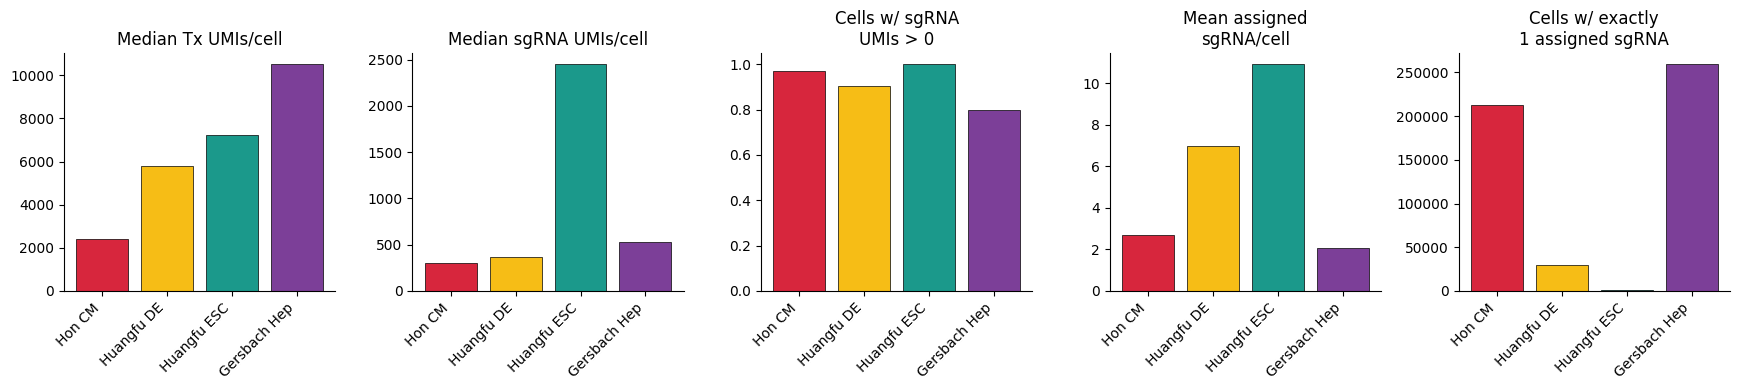

In [16]:
combined = gene_all[['dataset', 'short_name', 'umi_median']].merge(
    guide_all[['dataset', 'guide_umi_median', 'frac_cells_with_guide',
               'guides_per_cell_mean', 'n_cells_exactly_1_guide']],
    on='dataset'
)

key_metrics = [
    ('umi_median', 'Median Tx UMIs/cell'),
    ('guide_umi_median', 'Median sgRNA UMIs/cell'),
    ('frac_cells_with_guide', 'Cells w/ sgRNA\nUMIs > 0'),
    ('guides_per_cell_mean', 'Mean assigned\nsgRNA/cell'),
    ('n_cells_exactly_1_guide', 'Cells w/ exactly\n1 assigned sgRNA'),
]

fig, axes = plt.subplots(1, len(key_metrics), figsize=(3.5 * len(key_metrics), 4))

for ax, (col, title) in zip(axes, key_metrics):
    colors = [dataset_colors[ds] for ds in combined['dataset']]
    ax.bar(range(len(combined)), combined[col], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(combined)))
    ax.set_xticklabels(combined['short_name'], rotation=45, ha='right')
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
for ext in ("pdf", "png"):
    plt.savefig(OUTPUT_DIR / f"key_combined_metrics_comparison.{ext}", dpi=300, bbox_inches='tight')
plt.show()

## Metrics by Lane

Per-batch breakdown of the same metrics. Bars are colored by dataset.

In [17]:
gene_by_lane = gene_metrics_df[gene_metrics_df['batch'] != 'all'].copy()
guide_by_lane = guide_metrics_df[guide_metrics_df['batch'] != 'all'].copy()

gene_lane_cols = ['batch', 'dataset', 'short_name', 'n_cells', 'umi_median', 'mito_median']
if 'genes_median' in gene_by_lane.columns:
    gene_lane_cols.insert(-1, 'genes_median')

# Try merging gene+guide by (dataset, batch). Some datasets use different batch IDs
# across modalities (e.g. CC Perturb-seq splits RNA vs guide analysis sets), so fall
# back to matching by (dataset, n_cells) when the join is missing.
guide_cols = ['batch', 'dataset', 'guide_umi_median', 'guides_per_cell_mean']
lane_metrics = gene_by_lane[gene_lane_cols].merge(
    guide_by_lane[guide_cols],
    on=['batch', 'dataset'],
    how='left',
)

missing_mask = lane_metrics['guide_umi_median'].isna()
if missing_mask.any():
    for ds in lane_metrics.loc[missing_mask, 'dataset'].unique():
        g = guide_by_lane[guide_by_lane['dataset'] == ds].rename(columns={'batch': 'guide_batch'})
        if g.empty:
            continue
        patch = lane_metrics.loc[lane_metrics['dataset'] == ds, ['batch', 'dataset', 'n_cells']].merge(
            g[['guide_batch', 'dataset', 'n_cells', 'guide_umi_median', 'guides_per_cell_mean']],
            on=['dataset', 'n_cells'], how='left',
        )
        idx = lane_metrics.index[lane_metrics['dataset'] == ds]
        lane_metrics.loc[idx, 'guide_umi_median'] = patch['guide_umi_median'].values
        lane_metrics.loc[idx, 'guides_per_cell_mean'] = patch['guides_per_cell_mean'].values

lane_metrics['dataset'] = pd.Categorical(lane_metrics['dataset'], categories=present_datasets, ordered=True)
lane_metrics = lane_metrics.sort_values(['dataset', 'batch']).reset_index(drop=True)
lane_metrics

,batch,dataset,short_name,n_cells,umi_median,genes_median,mito_median,guide_umi_median,guides_per_cell_mean
0,IGVFDS0119GHBM,Hon_WTC11-cardiomyocyte-differentiation_TF-Per...,Hon CM,35038,2508.0,1470.0,4.269479,197.0,2.638906
1,IGVFDS0814DYDR,Hon_WTC11-cardiomyocyte-differentiation_TF-Per...,Hon CM,38859,3031.0,1705.0,3.063291,341.0,2.711135
2,IGVFDS0860HOHE,Hon_WTC11-cardiomyocyte-differentiation_TF-Per...,Hon CM,41117,2591.0,1543.0,3.139357,346.0,2.693606
3,IGVFDS1042ITOF,Hon_WTC11-cardiomyocyte-differentiation_TF-Per...,Hon CM,39931,2349.0,1396.0,3.031437,322.0,2.615061
4,IGVFDS1584ZJUM,Hon_WTC11-cardiomyocyte-differentiation_TF-Per...,Hon CM,40020,2844.0,1655.0,3.031407,377.0,2.729760
...,...,...,...,...,...,...,...,...,...
84,F3_S43,Gersbach_WTC11-hepatocyte-differentiation_TF-P...,Gersbach Hep,11979,7381.0,2872.0,3.715802,121.0,1.268303
85,F4_S44,Gersbach_WTC11-hepatocyte-differentiation_TF-P...,Gersbach Hep,15149,8201.0,3030.0,3.603825,147.0,1.413229
86,F5_S45,Gersbach_WTC11-hepatocyte-differentiation_TF-P...,Gersbach Hep,14709,7962.0,2979.0,3.517730,134.0,1.336053
87,F6_S46,Gersbach_WTC11-hepatocyte-differentiation_TF-P...,Gersbach Hep,15129,7831.0,2976.0,3.701068,137.0,1.355939


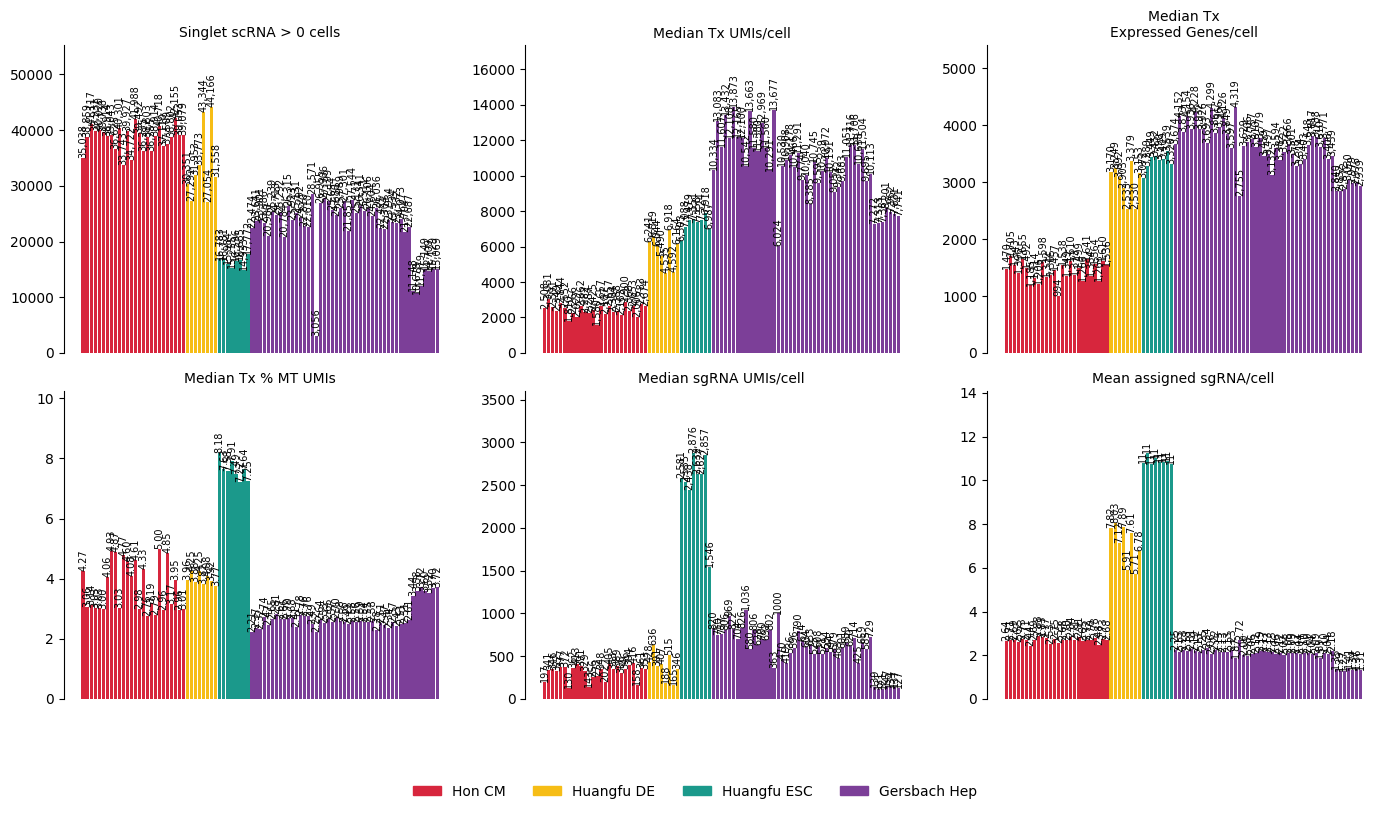

In [18]:
# 2x3 grid of per-lane metrics
lane_metrics_to_plot = [
    ('n_cells', 'Singlet scRNA > 0 cells'),
    ('umi_median', 'Median Tx UMIs/cell'),
    ('genes_median', 'Median Tx\nExpressed Genes/cell'),
    ('mito_median', 'Median Tx % MT UMIs'),
    ('guide_umi_median', 'Median sgRNA UMIs/cell'),
    ('guides_per_cell_mean', 'Mean assigned sgRNA/cell'),
]
lane_metrics_to_plot = [(c, t) for c, t in lane_metrics_to_plot if c in lane_metrics.columns]

n_plots = len(lane_metrics_to_plot)
ncols = 3
nrows = int(np.ceil(n_plots / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for ax, (col, title) in zip(axes, lane_metrics_to_plot):
    colors = [dataset_colors[ds] for ds in lane_metrics['dataset']]
    x = np.arange(len(lane_metrics))
    bars = ax.bar(x, lane_metrics[col], color=colors, edgecolor='none', width=0.8)
    for bar, val in zip(bars, lane_metrics[col]):
        if pd.notna(val):
            if val >= 1000:
                label = f'{val:,.0f}'
            elif val >= 10:
                label = f'{val:.0f}'
            else:
                label = f'{val:.2f}'
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), label,
                    ha='center', va='bottom', fontsize=7, rotation=90)
    ax.set_xticks([])
    ax.set_title(title, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ymax = lane_metrics[col].max()
    if pd.notna(ymax) and ymax > 0:
        ax.set_ylim(0, ymax * 1.25)

for ax in axes[n_plots:]:
    ax.set_visible(False)

legend_handles = [plt.Rectangle((0,0),1,1, color=dataset_colors[ds]) for ds in present_datasets]
fig.legend(legend_handles, present_short_names, loc='lower center', ncol=min(len(present_short_names), 5),
           bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
for ext in ("pdf", "png"):
    plt.savefig(OUTPUT_DIR / f"metrics_by_lane_comparison.{ext}", dpi=300, bbox_inches='tight')
plt.show()

In [19]:
lane_metrics.to_csv(OUTPUT_DIR / "metrics_by_lane.tsv", sep="\t", index=False)
print(f"Saved to {OUTPUT_DIR / 'metrics_by_lane.tsv'}")

Saved to /cellar/users/aklie/projects/tf_perturb_seq/docs/jamborees/2026_UTSW/working_groups/wg1_data_qc/pipeline_qc/results/cross_dataset_metrics/metrics_by_lane.tsv


---
# DONE!